# Analysis notebook: `dev_CRY_onspill-LH_1a`  

## Define analysis name

In [1]:
ana_label = "dev_CRY_onspill-LH_1a"

## Preamble

In [2]:
import sys
sys.path.append("..")
from preamble import *

## Load data

In [3]:
!ls ../../../output/results/dev_CRY_onspill-LH_1a

analysis.csv  dev_CRY_onspill-LH_1a.log   events.parquet  info.txt
cut_flow.csv  dev_CRY_onspill-LH_1a.yaml  hists.h5	  results.pkl


In [4]:
loader = Load(
    in_path = f"../../../output/results/{ana_label}"
)

[Load] ✅ Initialised with out_path=../../../output/results/dev_CRY_onspill-LH_1a


In [5]:
results = loader.load_pkl() 
# results_from_persistent = loader.load_all() # Persistent backup 

[Load] ✅ Successfully loaded results from ../../../output/results/dev_CRY_onspill-LH_1a/results.pkl


## Analyse results

### Cut flow

In [6]:
display(results["cut_flow"])

,Cut,Group,Events Passing,Absolute [%],Relative [%],Description
0,No cuts,NaN,1433396,100,100,No selection applied
1,has_trk_front,Preselect,1396050,97.395,97.395,Tracks intersect tracker entrance
2,has_trk_mid,Preselect,1396026,97.393,99.998,Tracks intersect tracker middle
3,one_track_per_event,Preselect,1052870,73.453,75.419,One track / event
4,is_reco_electron,Preselect,1010214,70.477,95.949,Electron track fits
5,is_downstream,Preselect,558423,38.958,55.278,Downstream tracks (p_z > 0 through tracker)
6,is_truth_electron,Preselect,142007,9.907,25.430,Track parents are electrons (truth PID)
7,good_trkqual,Tracker,114214,7.968,80.428,Track quality > 0.2
8,within_t0,Tracker,90883,6.340,79.573,t0 at tracker mid (640 < t_0 < 1650 ns)
9,within_t0err,Tracker,82609,5.763,90.896,Track fit t0 uncertainty (t0err < 0.9 ns)


### Efficiency & rates

In [7]:
display(results["analysis"])

Window,Inclusive,Wide,Extended,Signal
Generated,"41,100,000,000","41,100,000,000","41,100,000,000","41,100,000,000"
Selected,"9,610","9,370","1,518",213
Unvetoed,"6,230","6,095",946,141
Selection Eff [%],2.34e-05,2.28e-05,3.69e-06,5.18e-07
Selection Eff Err$-$ [%],-2.37e-07,-2.34e-07,-9.36e-08,-3.43e-08
Selection Eff Err$+$ [%],2.40e-07,2.37e-07,9.60e-08,3.67e-08
Veto Eff [%],35.172,34.952,37.681,33.803
Veto Eff Err$-$ [%],-0.486,-0.491,-1.235,-3.159
Veto Eff Err$+$ [%],0.489,0.494,1.251,3.310
Livetime [days],1.16e+04,9.14e+03,943.510,123.611


### Histograms

In [8]:
# Setup draw for this cutset
on_spill = "offspill" not in ana_label
draw = Draw(cutset_name=ana_label.split('_')[0], on_spill=on_spill)
# Define image directory
img_dir = f"../../../output/images/{ana_label}"
os.makedirs(img_dir, exist_ok=True)

[Load] ✅ Initialised with out_path=test_out
[pyprint] ⭐️ Initialised Print with verbose = False and precision = 1
[Plot] ⭐️ Initialised


[Plot] ✅ 	Wrote ../../../output/images/dev_CRY_onspill-LH_1a/h1o_1x3_mom_windows.png


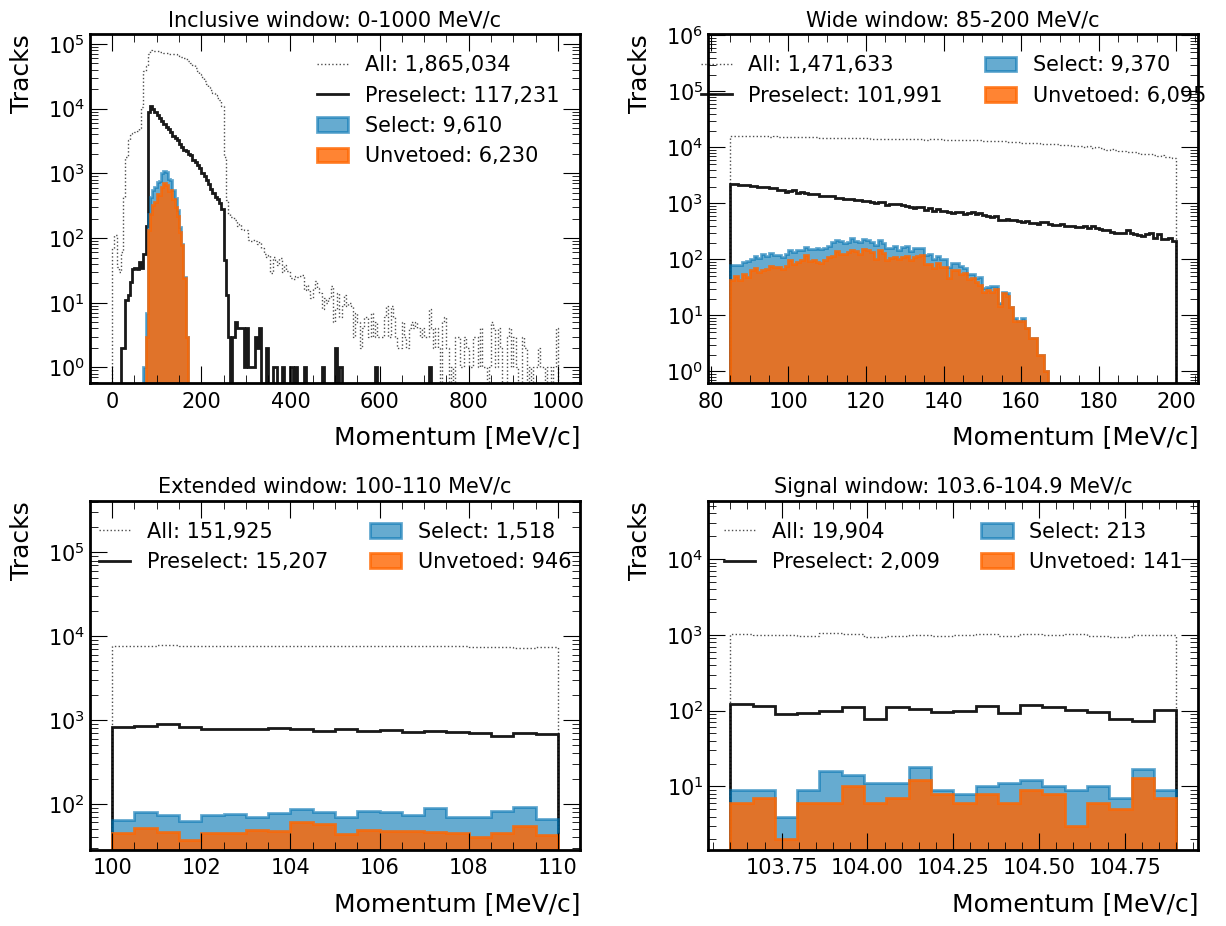

In [9]:
draw.plot_mom_windows(results["hists"], out_path=f"{img_dir}/h1o_1x3_mom_windows.png") 

[Plot] ✅ 	Wrote ../../../output/images/dev_CRY_onspill-LH_1a/h1o_3x3_summary.png


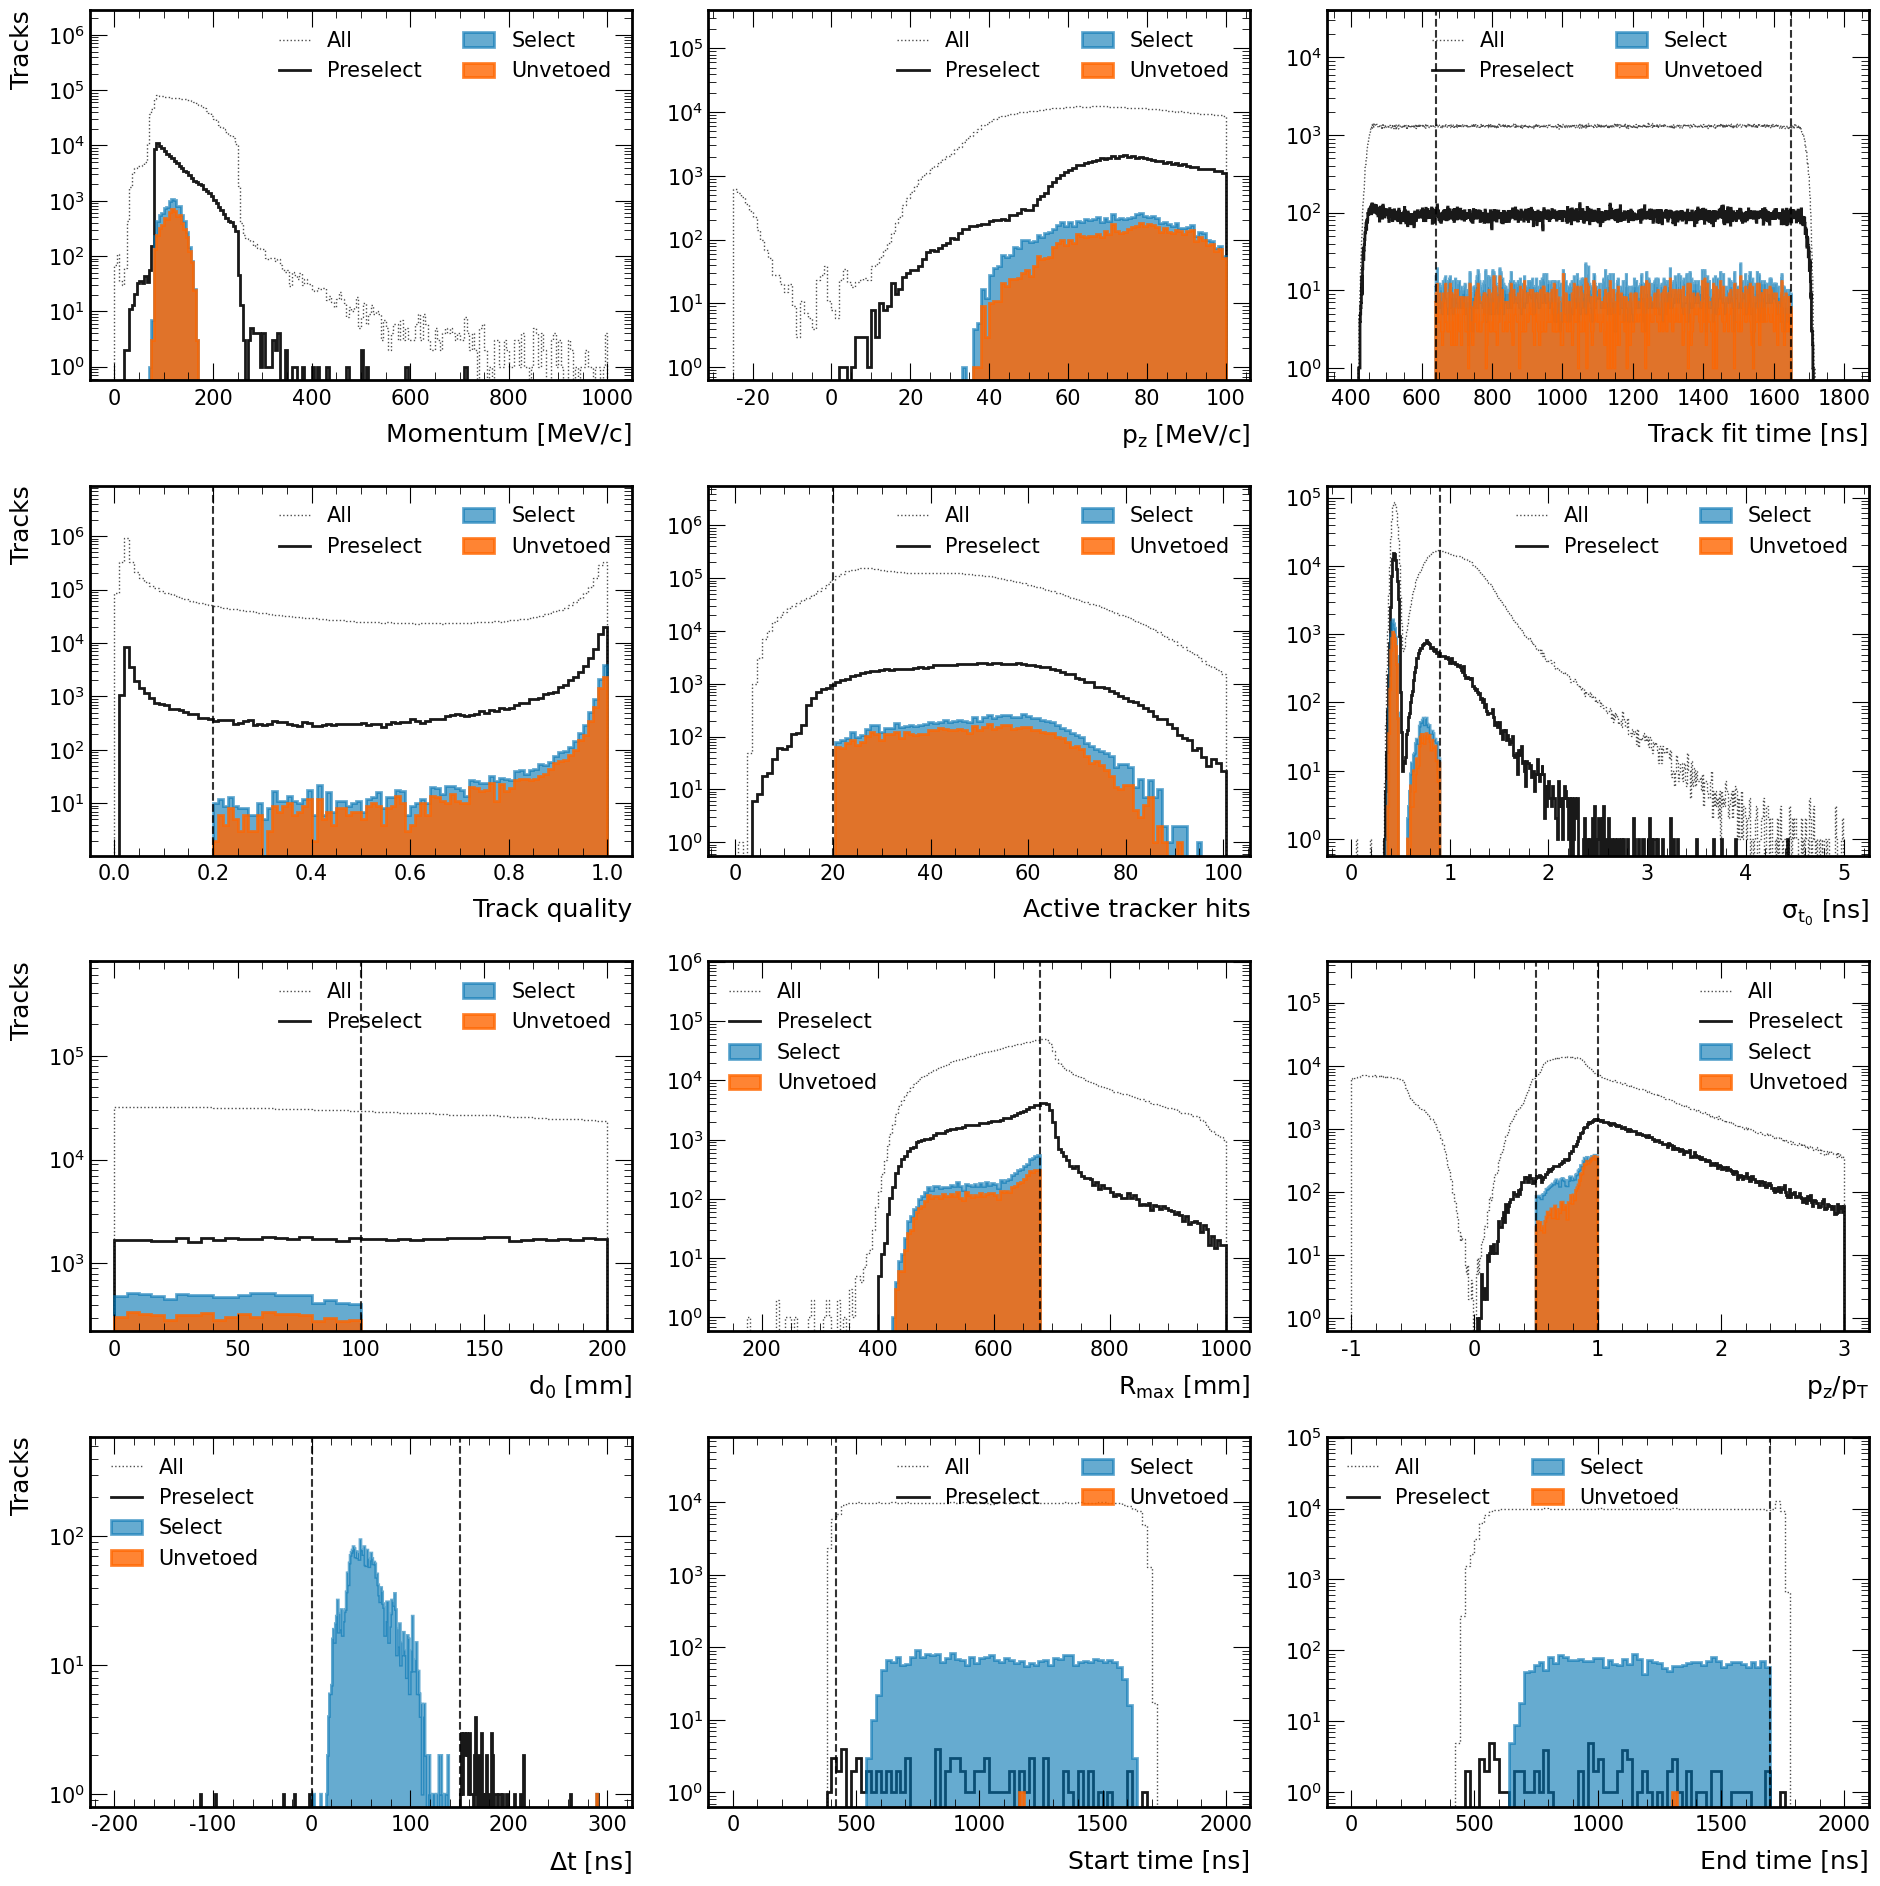

In [10]:
draw.plot_summary(results["hists"], out_path=f"{img_dir}/h1o_3x3_summary.png")

[Plot] ✅ 	Wrote ../../../output/images/dev_CRY_onspill-LH_1a/h1o_2x2_mom_summary.png


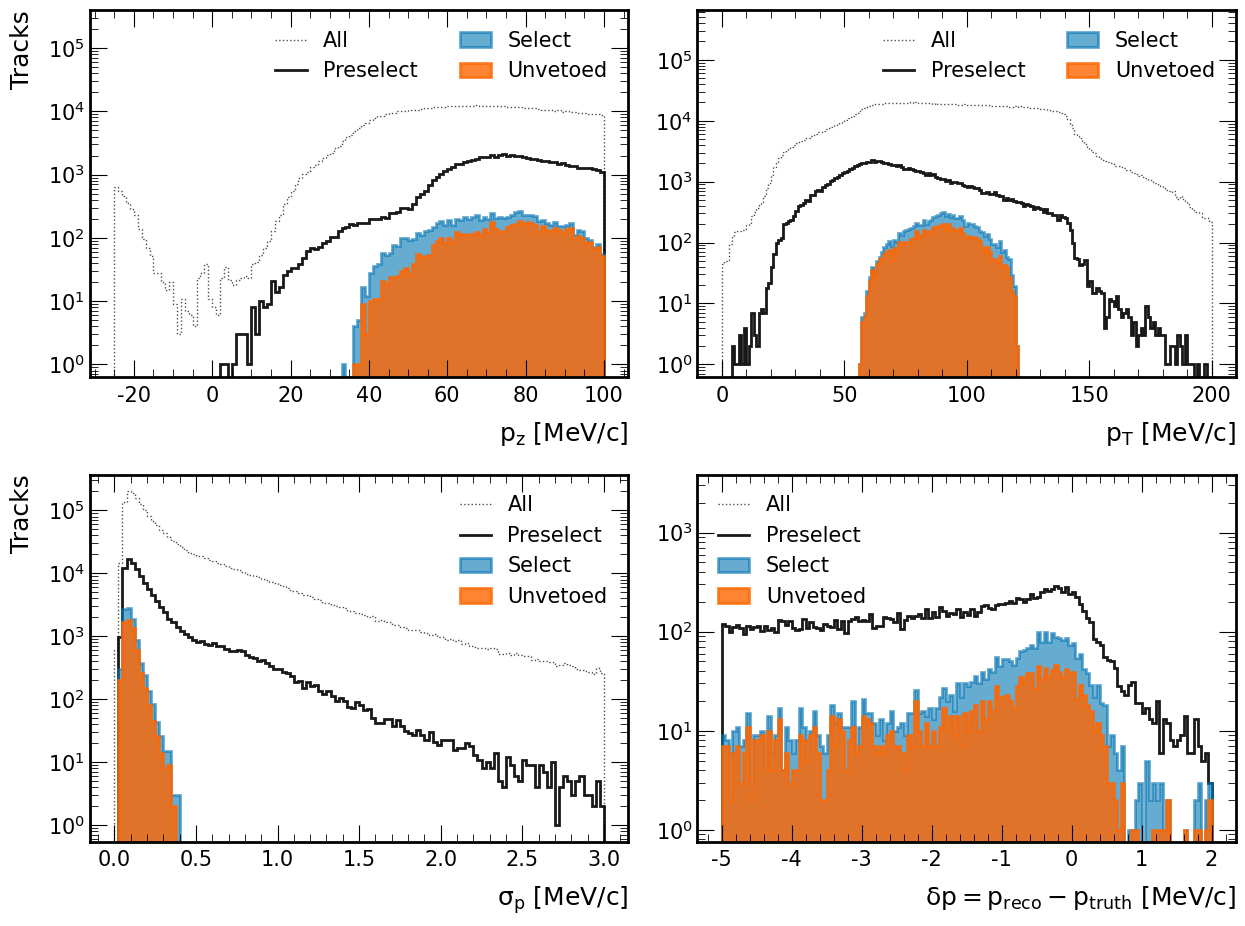

In [11]:
draw.plot_mom_summary(results["hists"], out_path=f"{img_dir}/h1o_2x2_mom_summary.png")

[Plot] ✅ 	Wrote ../../../output/images/dev_CRY_onspill-LH_1a/h1o_crv_z.png


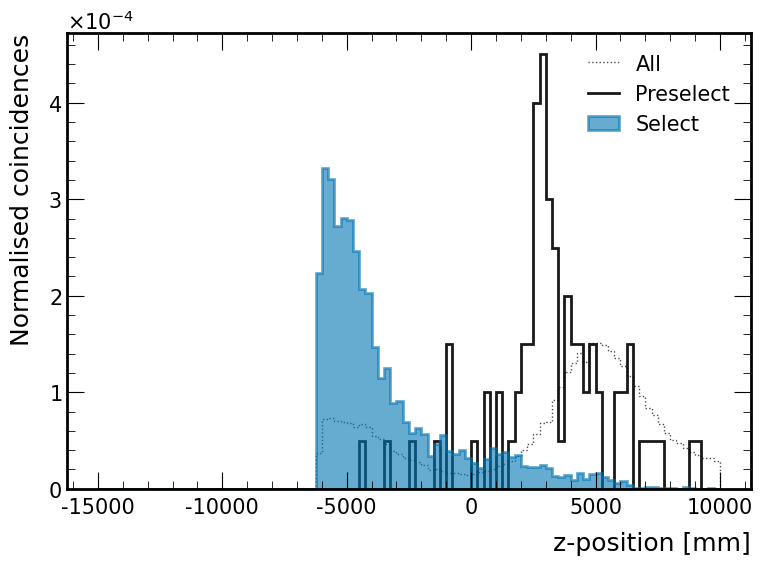

In [12]:
draw.plot_crv_z(results["hists"], out_path=f"{img_dir}/h1o_crv_z.png") 

[Plot] ✅ 	Wrote ../../../output/images/dev_CRY_onspill-LH_1a/h1_cosmic_parents.png


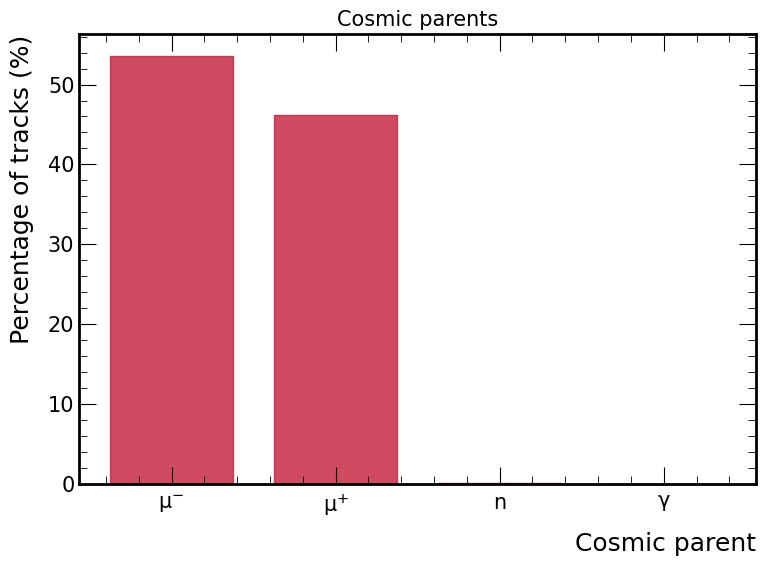

In [13]:
draw.draw_cosmic_parents_from_array(results["events"], out_path=f"{img_dir}/h1_cosmic_parents.png", percentage=True) 

### Background event info

In [14]:
# print(results["event_info"])

In [15]:
# if results["events"] is not None:
#     from pyutils.pyprint import Print
#     printer = Print()
#     printer.print_n_events(results["events"], n_events = len(results["events"]))